*1.Load Libraries*

In [107]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px 

*2.Load Dataset*

In [108]:
# -------------------- 2015,2016,2017,2018,------------------------>
df_2015 = pd.read_csv('../data/raw/2015.csv')
df_2016 = pd.read_csv('../data/raw/2016.csv')
df_2017 = pd.read_csv('../data/raw/2017.csv')
df_2018 = pd.read_csv('../data/raw/2018.csv')
df_2019 = pd.read_csv('../data/raw/2019.csv')
df_2020 = pd.read_csv('../data/raw/2020.csv')
df_2021 = pd.read_csv('../data/raw/2021.csv')
df_2023 = pd.read_csv('../data/raw/2023.csv')


In [109]:
# ------------------SHAPE--------------------------->
print('2015 dimension : ', df_2015.shape)
print('2016 dimension : ', df_2016.shape)
print('2017 dimension : ', df_2017.shape)
print('2018 dimension : ', df_2018.shape)
print('2019 dimension : ', df_2019.shape)
print('2020 dimension : ', df_2020.shape)
print('2021 dimension : ', df_2021.shape)
print('2023 dimension : ', df_2023.shape)

2015 dimension :  (158, 12)
2016 dimension :  (157, 13)
2017 dimension :  (155, 12)
2018 dimension :  (156, 9)
2019 dimension :  (156, 9)
2020 dimension :  (153, 20)
2021 dimension :  (149, 20)
2023 dimension :  (137, 19)


*3.Check How They Look Like Columns*

In [110]:
# --------------------2015-columns---------------------------->
print('COLUMNS 2015 :\n', df_2015.columns.to_list())

# --------------------2016-columns---------------------------->
print('COLUMNS 2016 :\n', df_2016.columns.to_list())

# --------------------2017-columns---------------------------->
print('COLUMNS 2017 :\n', df_2017.columns.to_list())

# --------------------2018-columns---------------------------->
print('COLUMNS 2018 :\n', df_2018.columns.to_list())

# --------------------2019-columns---------------------------->
print('COLUMNS 2019:\n', df_2019.columns.to_list())


COLUMNS 2015 :
 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
COLUMNS 2016 :
 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
COLUMNS 2017 :
 ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
COLUMNS 2018 :
 ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
COLUMNS 2019:
 ['Overall rank', 'Country o

In [111]:
# 2020 to 2024 dataset has some new different columns ,Firstly  deal with that
df_2020.columns.tolist()

['Country name',
 'Regional indicator',
 'Ladder score',
 'Standard error of ladder score',
 'upperwhisker',
 'lowerwhisker',
 'Logged GDP per capita',
 'Social support',
 'Healthy life expectancy',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption',
 'Ladder score in Dystopia',
 'Explained by: Log GDP per capita',
 'Explained by: Social support',
 'Explained by: Healthy life expectancy',
 'Explained by: Freedom to make life choices',
 'Explained by: Generosity',
 'Explained by: Perceptions of corruption',
 'Dystopia + residual']

In [112]:
# Concatenate columns from 2020, 2021, 2023
df_2021_2023 = [df_2020, df_2021, df_2023]

In [113]:
columns_to_drop = [
     'upperwhisker', 'lowerwhisker',
    'Standard error of ladder score',
    'Ladder score in Dystopia', 'Dystopia + residual'
] 
# Drop all columns starting with 'Explained by'
columns_to_drop += [col for col in df_2021_2023[0].columns if col.startswith('Explained by')]


In [114]:
for i in range(len(df_2021_2023)):
    df_2021_2023[i] = df_2021_2023[i].drop(columns=columns_to_drop)


In [115]:
df_2020, df_2021, df_2023 = df_2021_2023


In [116]:
df_2020.columns

Index(['Country name', 'Regional indicator', 'Ladder score',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

4. Standardize Column Names

In [117]:
# Different years use different names for the same data -→ unify them.

rename_dict = {
    "Country or region": "Country" ,
    'Country name':'Country',
    
    'Regional indicator':'Region',

    "Happiness Score": "HappinessScore",
    "Happiness.Score": "HappinessScore",
    "Score":"HappinessScore",
    'Ladder score':"HappinessScore",
    
    # "Life Ladder": "HappinessScore",
    "Happiness.Rank":"HappinessRank",
    "Happiness Rank":"HappinessRank",
    "Overall rank":"HappinessRank",

    "Economy (GDP per Capita)": "GDP per Capita",
    "Economy..GDP.per.Capita.": "GDP per Capita",
    'Logged GDP per capita':'GDP per Capita',
    "GDP per capita":"GDP per Capita",

    "Healthy life expectancy": "LifeExpectancy",
    "Health (Life Expectancy)": "LifeExpectancy",
    "Health..Life.Expectancy.":"LifeExpectancy",

    "Social support": "SocialSupport",
    "Family": "SocialSupport",
    "Freedom to make life choices": "Freedom",
    "Freedom": "Freedom",
    
    "Perceptions of corruption": "Corruption",
    "Trust (Government Corruption)": "Corruption",
    "Trust..Government.Corruption.":"Corruption"
}

# Apply rename for all dataframes
df_2015.rename(columns=rename_dict, inplace=True)
df_2016.rename(columns=rename_dict, inplace=True)
df_2017.rename(columns=rename_dict, inplace=True)
df_2018.rename(columns=rename_dict, inplace=True)
df_2019.rename(columns=rename_dict, inplace=True)
df_2020.rename(columns=rename_dict, inplace=True)
df_2021.rename(columns=rename_dict, inplace=True)
df_2023.rename(columns=rename_dict, inplace=True)


In [118]:
# Add the year columns according to dataset
# ----------------------Adding Years-------------------->
df_2015['Year'] = 2015
df_2016['Year'] = 2016
df_2017['Year'] = 2017
df_2018['Year'] = 2018
df_2019['Year'] = 2019
df_2020['Year'] = 2020
df_2021['Year'] = 2021
df_2023['Year'] = 2023
# Let check it
df_2018.columns

Index(['HappinessRank', 'Country', 'HappinessScore', 'GDP per Capita',
       'SocialSupport', 'LifeExpectancy', 'Freedom', 'Generosity',
       'Corruption', 'Year'],
      dtype='object')

5.Mergs-dataset

In [119]:
# ------------------------------CONCATINATION------------------------------>
df = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019,df_2020,df_2021, df_2023], ignore_index=True)

# let see the first five data
df.head()

,Country,Region,HappinessRank,HappinessScore,Standard Error,GDP per Capita,SocialSupport,LifeExpectancy,Freedom,Corruption,Generosity,Dystopia Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low,Dystopia.Residual
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN,NaN


In [120]:
# CheckOut the Dimension of dataset
print(f"Rows & Columns : {df.shape}")

Rows & Columns : (1221, 18)


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    1221 non-null   object 
 1   Region                     617 non-null    object 
 2   HappinessRank              782 non-null    float64
 3   HappinessScore             1221 non-null   float64
 4   Standard Error             158 non-null    float64
 5   GDP per Capita             1221 non-null   float64
 6   SocialSupport              1221 non-null   float64
 7   LifeExpectancy             1220 non-null   float64
 8   Freedom                    1221 non-null   float64
 9   Corruption                 1220 non-null   float64
 10  Generosity                 1221 non-null   float64
 11  Dystopia Residual          315 non-null    float64
 12  Year                       1221 non-null   int64  
 13  Lower Confidence Interval  157 non-null    float

In [122]:
# Check the missing values
df.isnull().sum().sort_values(ascending=False)

Whisker.high                 1066
Dystopia.Residual            1066
Whisker.low                  1066
Lower Confidence Interval    1064
Upper Confidence Interval    1064
Standard Error               1063
Dystopia Residual             906
Region                        604
HappinessRank                 439
LifeExpectancy                  1
Corruption                      1
Country                         0
HappinessScore                  0
GDP per Capita                  0
Freedom                         0
SocialSupport                   0
Year                            0
Generosity                      0
dtype: int64

In [123]:
# Drive Statistical Analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HappinessRank,782.0,78.698210,45.182384,1.000000,40.000000,79.000000,118.000000,158.000000
HappinessScore,1221.0,5.427635,1.121245,1.859000,4.574000,5.411000,6.239000,7.842000
Standard Error,158.0,0.047885,0.017146,0.018480,0.037268,0.043940,0.052300,0.136930
GDP per Capita,1221.0,3.962828,4.142764,0.000000,0.837920,1.270740,8.798580,11.660000
SocialSupport,1221.0,0.981087,0.302850,0.000000,0.794000,0.926240,1.218770,1.644000
LifeExpectancy,1220.0,23.654590,31.051613,0.000000,0.590089,0.817500,61.998500,77.280000
Freedom,1221.0,0.546395,0.228688,0.000000,0.383000,0.537825,0.735000,0.974998
Corruption,1220.0,0.342543,0.319865,0.000000,0.076000,0.169745,0.708000,0.939000
Generosity,1221.0,0.138833,0.169957,-0.300907,0.038000,0.146000,0.243530,0.838075
Dystopia Residual,315.0,2.212032,0.558728,0.328580,1.884135,2.211260,2.563470,3.837720


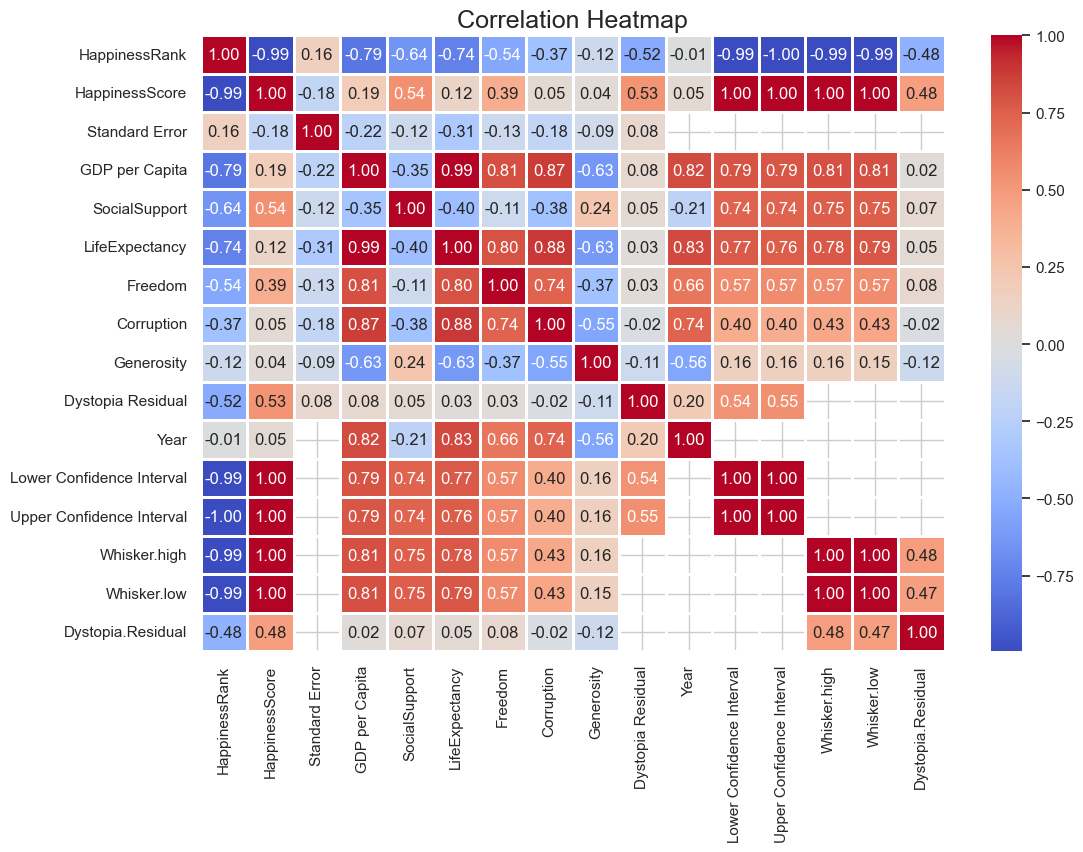

In [124]:
# selection the numerical feature and catogorical feature seprately
num_col = df.select_dtypes(include=['int64','float64'] )

# show the correlstion through heat map
plt.figure(figsize=(12, 8))
sns.heatmap(num_col.corr(),
            annot=True, cmap = 'coolwarm', fmt='.2f', linewidths = 2)
plt.title("Correlation Heatmap", fontsize=18)
plt.show()

“Based on the correlation heatmap, Social Support, GDP per Capita, and Freedom exhibit the strongest positive correlations with the Happiness Score. This indicates that financial stability, the ability to rely on others, and personal freedom are major contributors to happiness.

Life Expectancy shows a moderate correlation, suggesting that better health conditions positively affect happiness, but not as strongly as economic or social factors.

Generosity has a weak positive relationship with happiness, while Corruption is negatively correlated, meaning higher corruption tends to reduce happiness levels.”

## Feature Selection

In [125]:
df.columns

Index(['Country', 'Region', 'HappinessRank', 'HappinessScore',
       'Standard Error', 'GDP per Capita', 'SocialSupport', 'LifeExpectancy',
       'Freedom', 'Corruption', 'Generosity', 'Dystopia Residual', 'Year',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Whisker.high', 'Whisker.low', 'Dystopia.Residual'],
      dtype='object')

In [126]:
df_final = df[[
        'Year',
        'Corruption',
        'GDP per Capita',
        'SocialSupport',
        'LifeExpectancy',
        'Freedom',
       'Generosity',
        'HappinessScore',
    ]]



In [127]:
df_final.head()

,Year,Corruption,GDP per Capita,SocialSupport,LifeExpectancy,Freedom,Generosity,HappinessScore
0,2015,0.41978,1.39651,1.34951,0.94143,0.66557,0.29678,7.587
1,2015,0.14145,1.30232,1.40223,0.94784,0.62877,0.43630,7.561
2,2015,0.48357,1.32548,1.36058,0.87464,0.64938,0.34139,7.527
3,2015,0.36503,1.45900,1.33095,0.88521,0.66973,0.34699,7.522
4,2015,0.32957,1.32629,1.32261,0.90563,0.63297,0.45811,7.427


In [128]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            1221 non-null   int64  
 1   Corruption      1220 non-null   float64
 2   GDP per Capita  1221 non-null   float64
 3   SocialSupport   1221 non-null   float64
 4   LifeExpectancy  1220 non-null   float64
 5   Freedom         1221 non-null   float64
 6   Generosity      1221 non-null   float64
 7   HappinessScore  1221 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 76.4 KB


In [129]:
df_final.to_csv('../data/processed/world_happiness_cleaned.csv', index=False)


In [130]:
df_final.columns

Index(['Year', 'Corruption', 'GDP per Capita', 'SocialSupport',
       'LifeExpectancy', 'Freedom', 'Generosity', 'HappinessScore'],
      dtype='object')

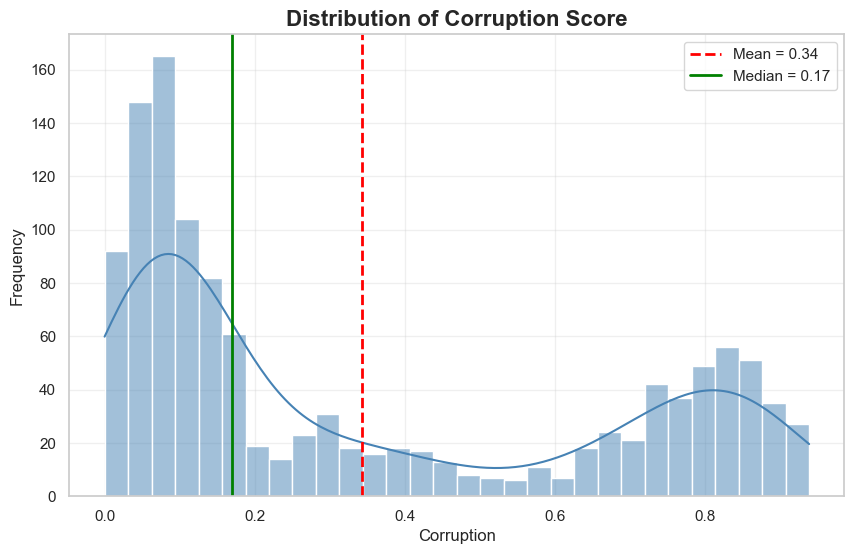

In [131]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_final['Corruption'],
    bins=30,
    kde=True,
    color='steelblue'
)

# Mean & Median (FIXED)
mean_val = df_final['Corruption'].mean()
median_val = df_final['Corruption'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f"Median = {median_val:.2f}")

plt.title('Distribution of Corruption Score', fontsize=16, fontweight='bold')
plt.xlabel('Corruption', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Description

This histogram shows the distribution of corruption scores across countries.
The red dashed line (mean) and green solid line (median) help assess skewness.
If the mean is greater than the median, the distribution is right-skewed, indicating more countries with lower corruption scores and fewer with very high corruption.

Available columns: ['Year', 'Corruption', 'GDP per Capita', 'SocialSupport', 'LifeExpectancy', 'Freedom', 'Generosity', 'HappinessScore']


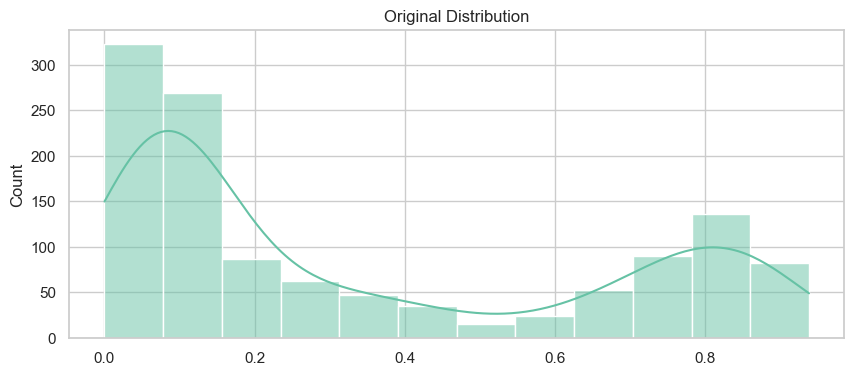

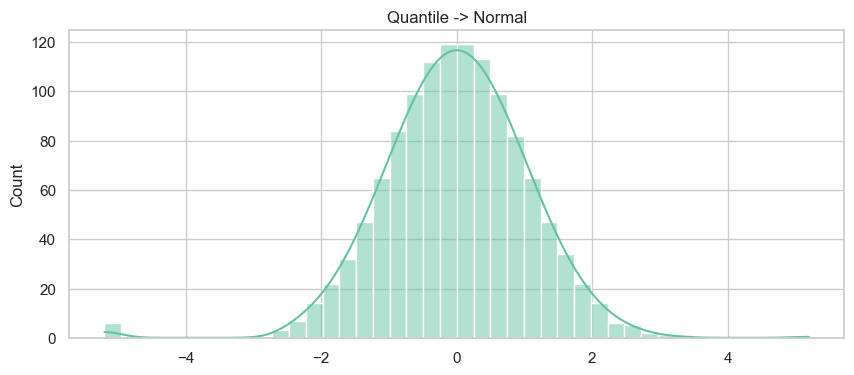

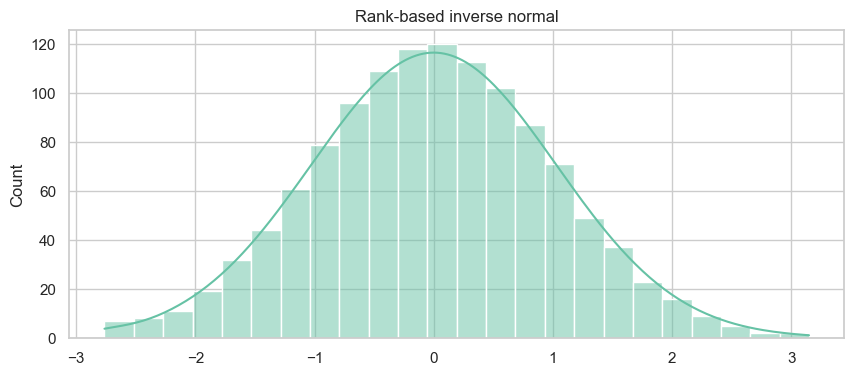

In [132]:
# Check available columns and perform case-insensitive lookup
print('Available columns:', df_final.columns.tolist())
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
import scipy.stats as stats

# requested column name (case-insensitive)
col_requested = 'Corruption'  # change this if you want a different column
cols = df_final.columns.tolist()
matches = [c for c in cols if c.lower() == col_requested.lower()]
if not matches:
    raise KeyError(f"Column '{col_requested}' not found. Available: {cols}")
col = matches[0]
x = df_final[col].dropna().values.reshape(-1,1)


# 1) Original Distribution
plt.figure(figsize=(10,4))
sns.histplot(x.squeeze(), kde=True)
plt.title('Original Distribution')
plt.show()
# 2) Standard Scaling (mean=0, std=1)
qt = QuantileTransformer(output_distribution='normal', random_state=0)
x_q = qt.fit_transform(x)
plt.figure(figsize=(10,4))
sns.histplot(x_q.squeeze(), kde=True)
plt.title('Quantile -> Normal')
plt.show()

# 3) Rank-based inverse normal (robust)
ranks = stats.rankdata(x.squeeze()) / (len(x) + 1)
x_rank_norm = stats.norm.ppf(ranks)
plt.figure(figsize=(10,4))
sns.histplot(x_rank_norm, kde=True)
plt.title('Rank-based inverse normal')
plt.show()



Description: Distribution Transformations of the Corruption Variable

This analysis applies multiple data transformation techniques to the corruption variable in order to understand its distribution and improve normality for further statistical analysis and modeling.


4. Quantile Transformation (Normal)

This transformation forces the data to follow a normal distribution by mapping quantiles of the original data to a normal distribution.
It is particularly useful when normality is required, such as in linear models or parametric statistical tests.

5. Rank-Based Inverse Normal Transformation

This robust method ranks the data and converts it into a normal distribution using the inverse normal function.
It is less sensitive to outliers and ensures a smooth, symmetric distribution.



In [133]:
df_final.columns = df_final.columns.str.strip().str.replace('','').str.lower()

In [134]:
cat_cols = df_final.select_dtypes(include='object')
num_col =df_final.select_dtypes(include=['int64','float64'])

In [135]:
df_final.isnull().sum()

year              0
corruption        1
gdp per capita    0
socialsupport     0
lifeexpectancy    1
freedom           0
generosity        0
happinessscore    0
dtype: int64

In [136]:
df_final[num_col.columns] =df_final[num_col.columns].fillna(df_final[num_col.columns].median())

C:\Users\Al Hafiz Enterprises\AppData\Local\Temp\ipykernel_2680\1214688129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[num_col.columns] =df_final[num_col.columns].fillna(df_final[num_col.columns].median())


In [137]:
df_2018.groupby('Country')['HappinessScore'].mean().sort_values(ascending=False)

Country
Finland                     7.632
Norway                      7.594
Denmark                     7.555
Iceland                     7.495
Switzerland                 7.487
                            ...  
Yemen                       3.355
Tanzania                    3.303
South Sudan                 3.254
Central African Republic    3.083
Burundi                     2.905
Name: HappinessScore, Length: 156, dtype: float64

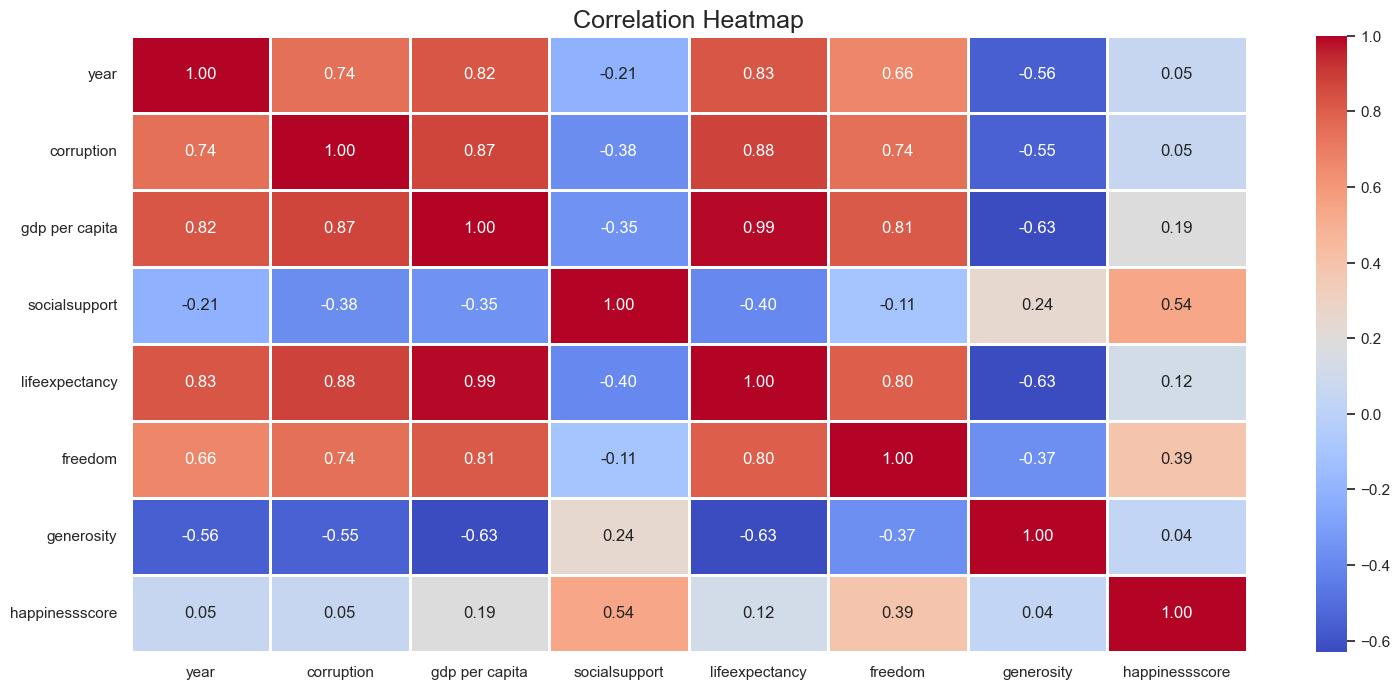

In [138]:
# selection the numerical feature and catogorical feature seprately
num_col = df_final.select_dtypes(include=['int64','float64'] )

# show the correlstion through heat map
plt.figure(figsize=(18, 8))
sns.heatmap(num_col.corr(),
            annot=True, cmap = 'coolwarm', fmt='.2f', linewidths = 2)
plt.title("Correlation Heatmap", fontsize=18)
plt.show()

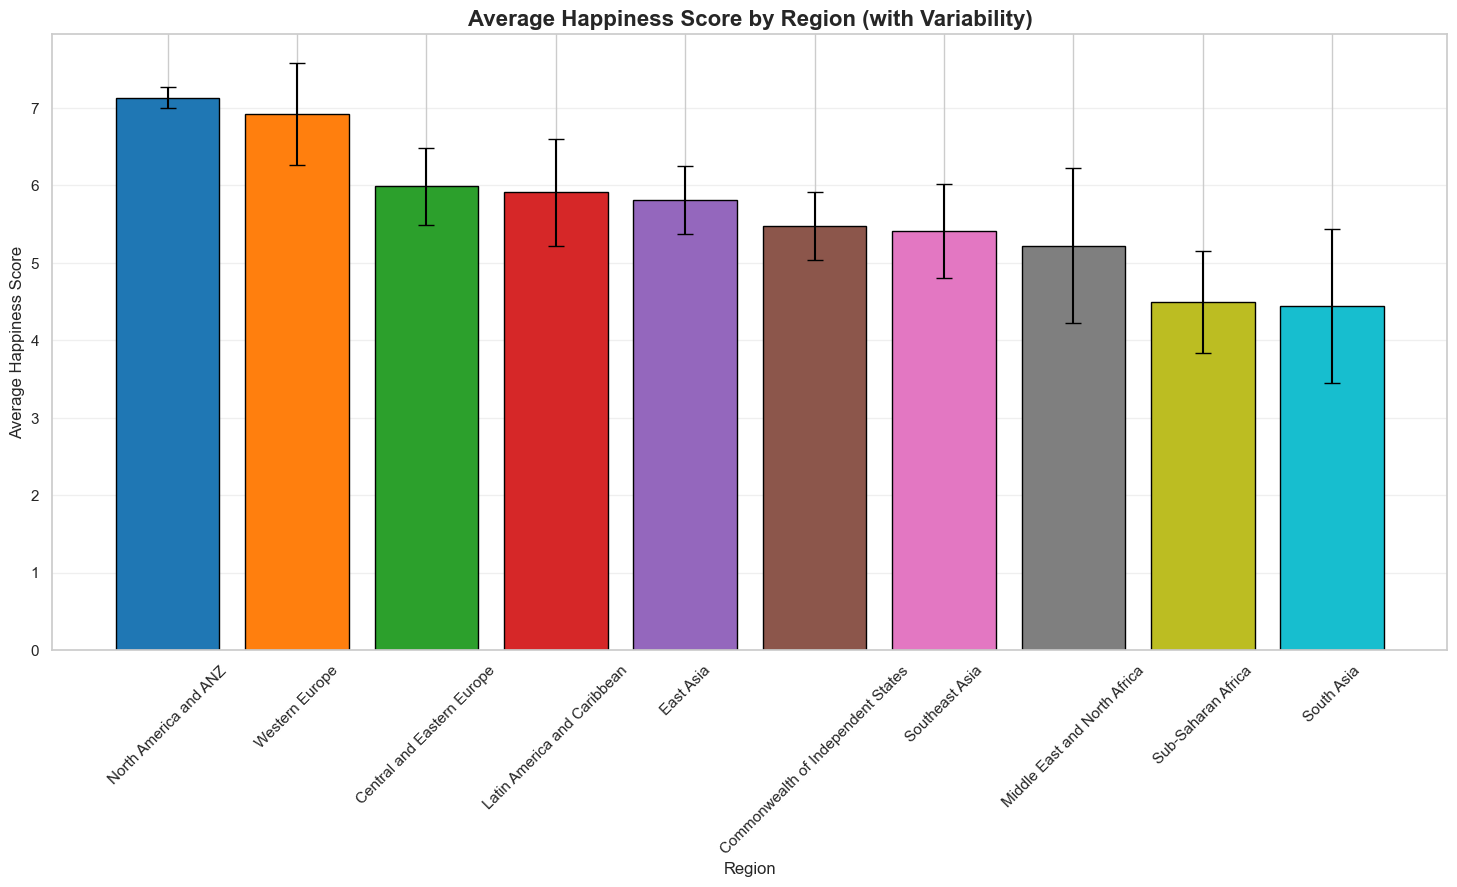

In [139]:


region_stats = df_2021.groupby('Region')['HappinessScore'] \
    .agg(['mean', 'std']) \
    .sort_values('mean', ascending=False)

plt.figure(figsize=(18,8))

# Generate different colors using a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(region_stats)))

plt.bar(
    region_stats.index,
    region_stats['mean'],
    yerr=region_stats['std'],
    capsize=6,
    color=colors,
    edgecolor='black'
)

plt.title('Average Happiness Score by Region (with Variability)',
          fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()



Description

This bar plot compares average happiness scores across regions.
The whiskers (error bars) represent the standard deviation, showing how much happiness varies among countries within each region.
Regions with larger whiskers have more unequal happiness levels.

Pairplot (Advanced EDA)

In [140]:
df_final.columns.tolist()

['year',
 'corruption',
 'gdp per capita',
 'socialsupport',
 'lifeexpectancy',
 'freedom',
 'generosity',
 'happinessscore']

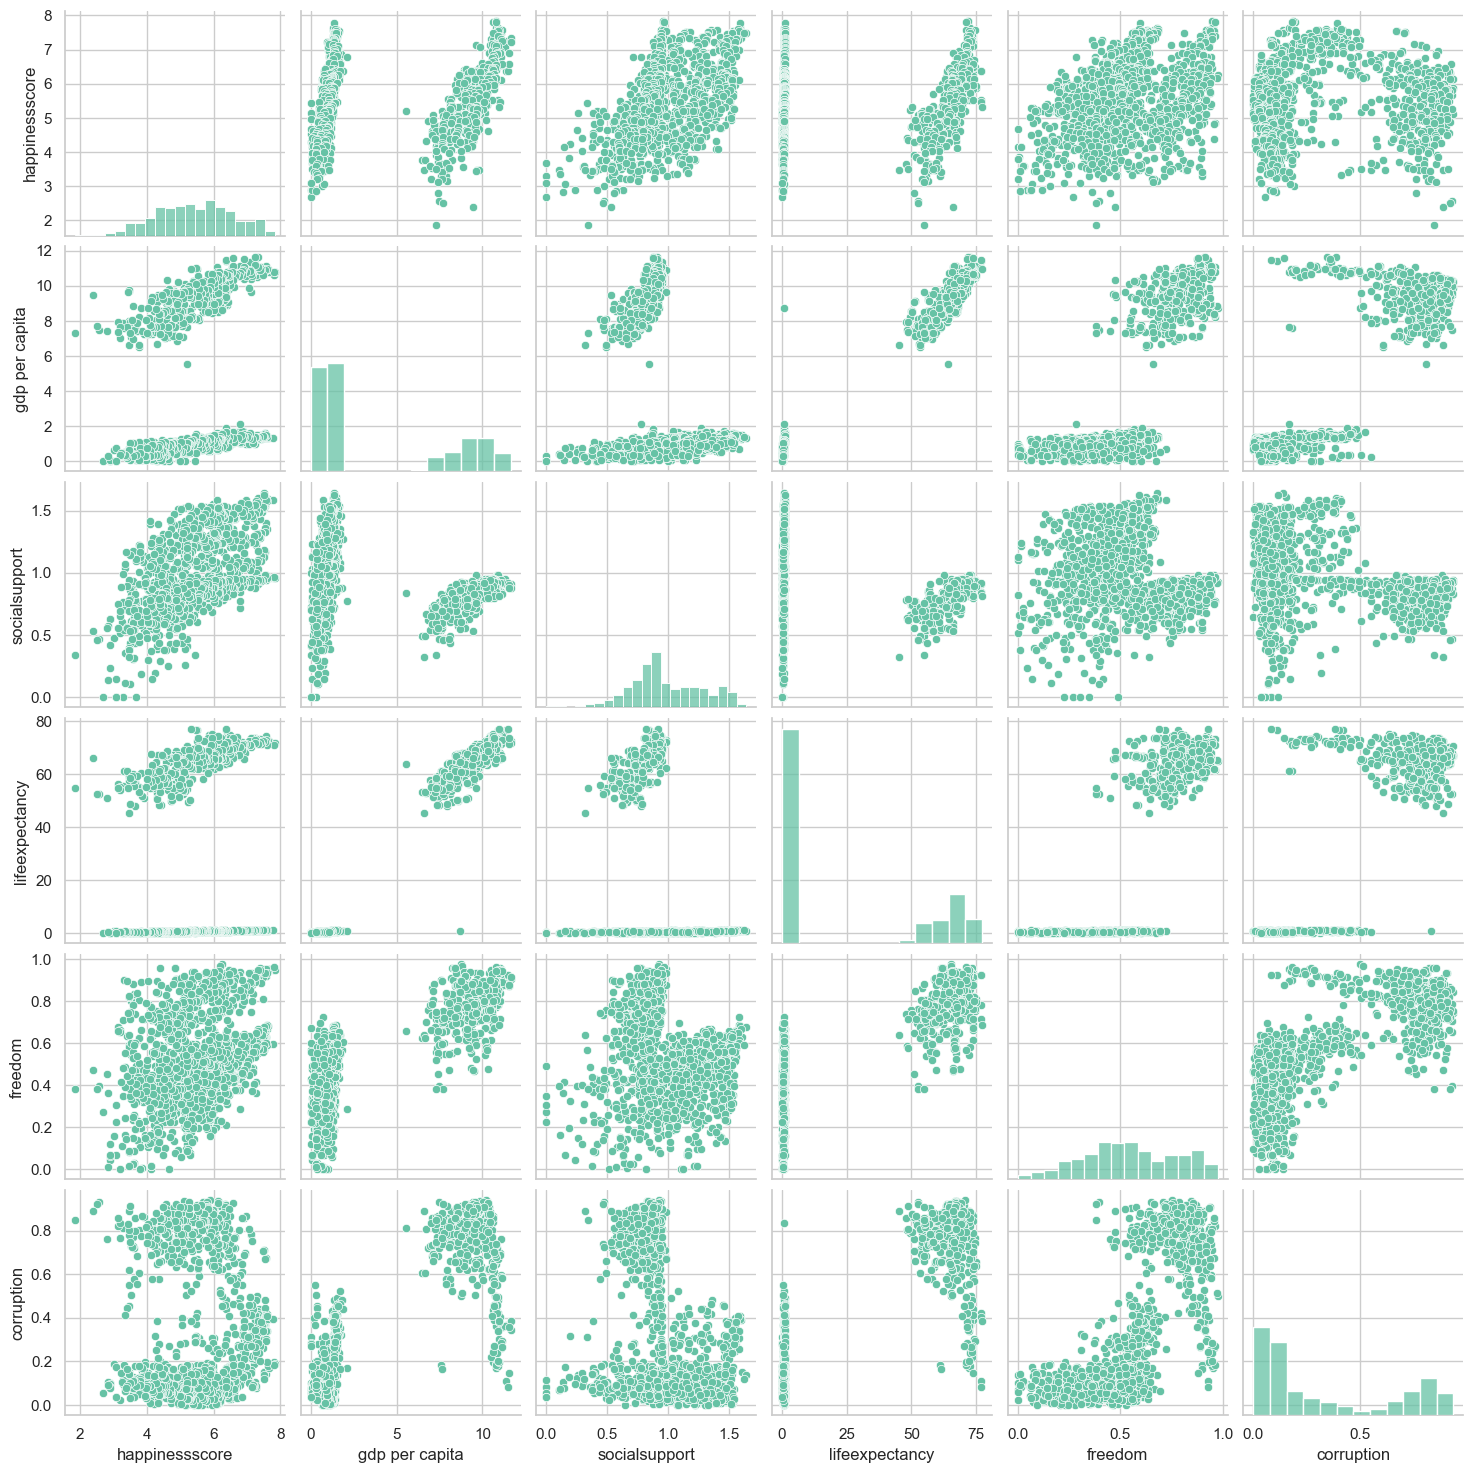

In [141]:
sns.pairplot(
    df_final[['happinessscore',
        'gdp per capita',
        'socialsupport',
        'lifeexpectancy',
        'freedom',
        'corruption']]
)

plt.show()

Description

This pairplot visualizes the pairwise relationships among key factors influencing happiness, including happiness score, GDP per capita, social support, life expectancy, freedom, and corruption.

The diagonal plots show the distribution of each variable, helping us understand how values are spread.

The scatter plots show how two variables relate to each other.

A positive relationship is visible between happiness score and GDP per capita, social support, life expectancy, and freedom.

Corruption shows a negative relationship with happiness score, indicating that higher corruption is associated with lower happiness.

The pairplot helps identify important features, correlations, and possible outliers before applying statistical or machine learning models.

Scatter + Trend Line

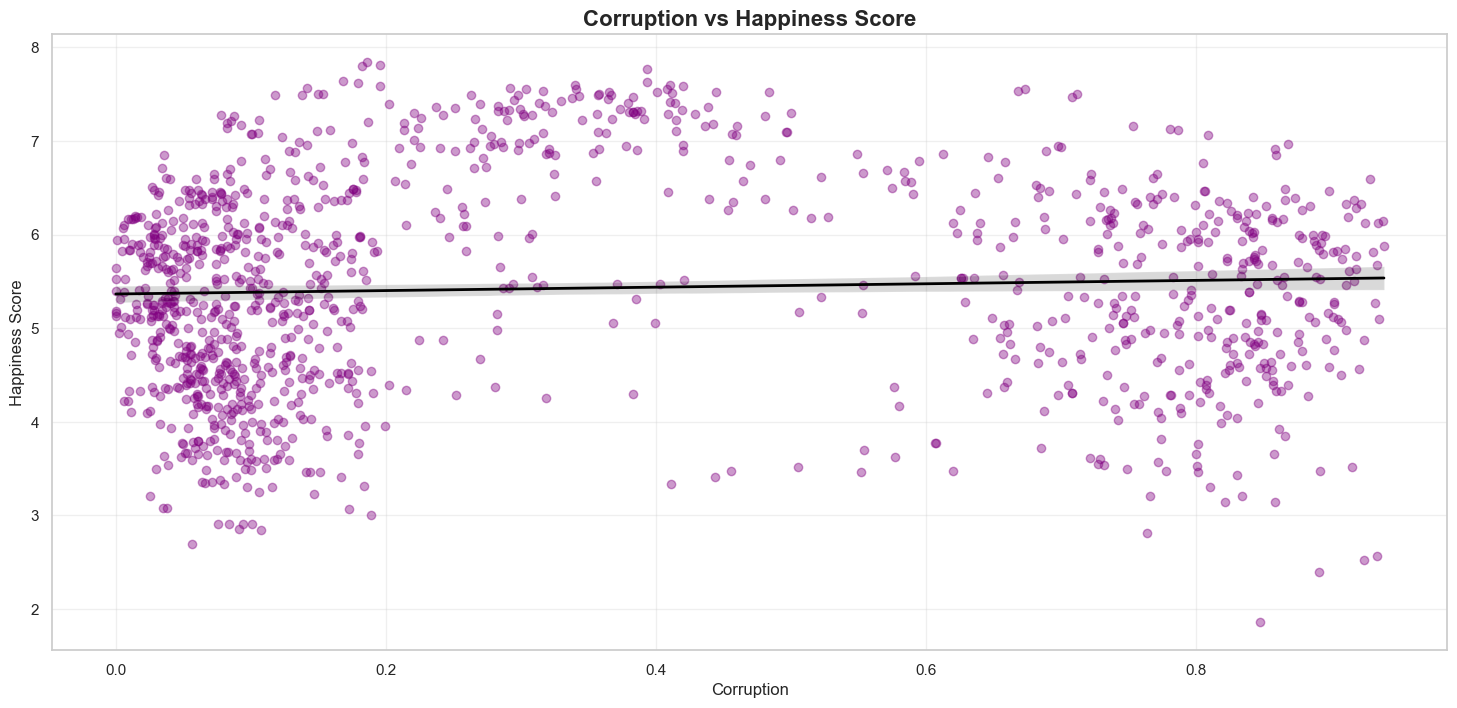

In [161]:
plt.figure(figsize=(18,8))

sns.regplot(
    x='corruption',
    y='happinessscore',
    data=df_final,
    scatter_kws={'alpha':0.4, 'color':'purple'},
    line_kws={'color':'black', 'linewidth':2}
)

plt.title('Corruption vs Happiness Score', fontsize=16, fontweight='bold')
plt.xlabel('Corruption', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.grid(alpha=0.3)

plt.show()


Description

This graph shows a negative relationship between corruption and happiness.
The downward-sloping regression line indicates that higher corruption is associated with lower happiness, making corruption a significant negative predictor of well-being.

Box Plot

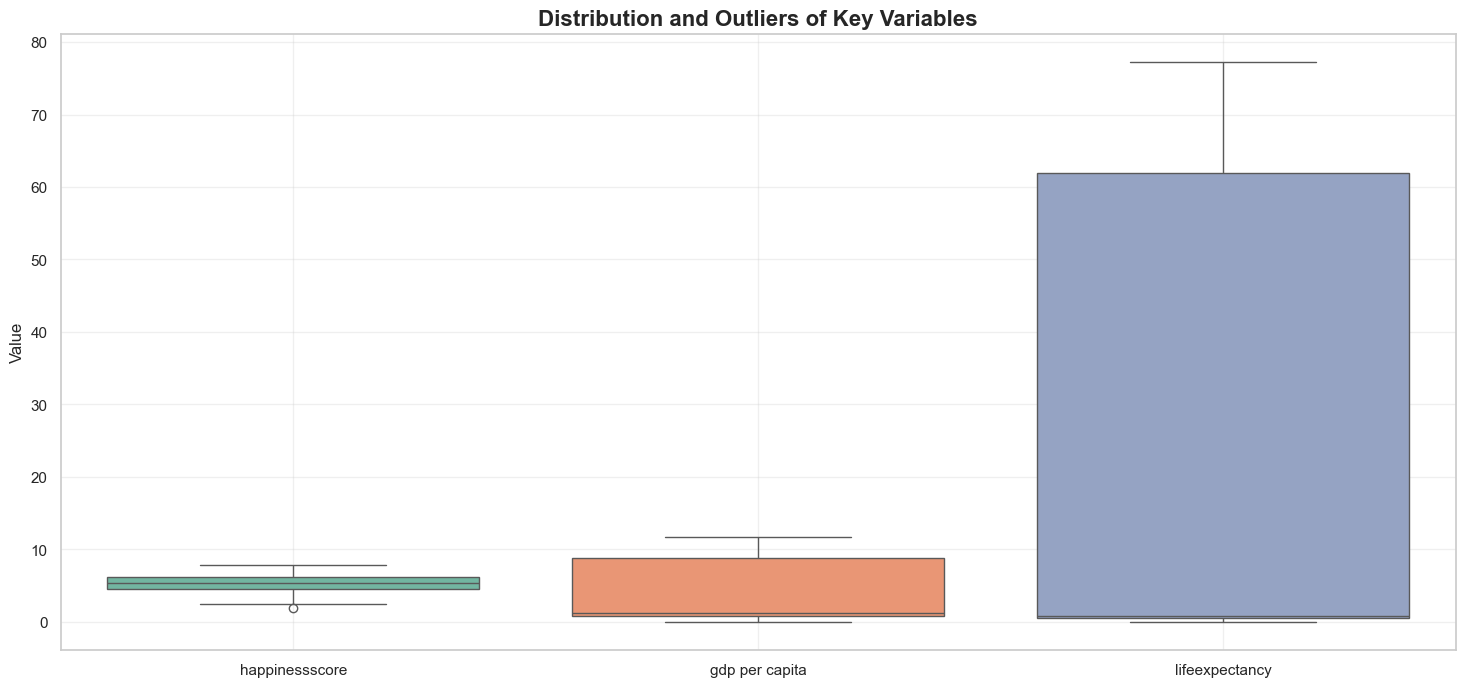

In [158]:
plt.figure(figsize=(18,8))

sns.boxplot(
    data=df_final[['happinessscore', 'gdp per capita', 'lifeexpectancy']],
    palette='Set2'
)

plt.title('Distribution and Outliers of Key Variables', fontsize=16, fontweight='bold')
plt.ylabel('Value', fontsize=12)
plt.grid(alpha=0.3)

plt.show()


Description

The box plot visualizes median, quartiles, whiskers, and outliers for major indicators.
Whiskers represent the normal data range, while points beyond them indicate outliers.
GDP per capita shows more extreme outliers compared to happiness scores.

Line Plot

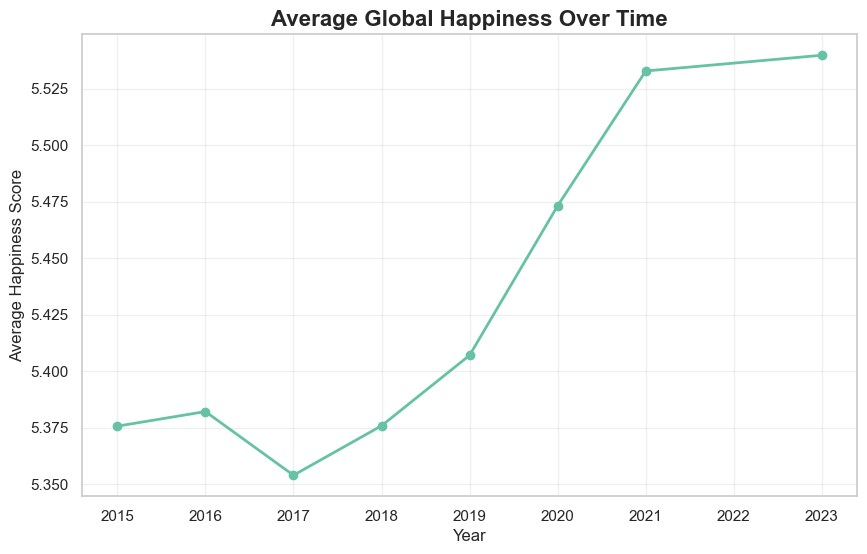

In [151]:
plt.figure(figsize=(10,6))

df_final.groupby('year')['happinessscore'].mean().plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title('Average Global Happiness Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.grid(alpha=0.3)

plt.show()


Description

This line plot shows how average global happiness changes over time.
The trend helps identify whether happiness is improving or declining globally, highlighting the long-term impact of economic, social, and political factors.